# 1、数据预处理

In [33]:
import os
import numpy as np
import scipy.io as sio
from tqdm import tqdm
from pyts.image import GramianAngularField
from skimage.transform import resize

In [34]:
# 数据路径
DE_PATH = "./驱动端"
FE_PATH = "./风扇端"

# 输出路径 (建议改个名字区分)
SAVE_PATH = "./CWRU_GAF128"

# 滑窗参数
WINDOW_SIZE = 1024
OVERLAP = 512
STEP = WINDOW_SIZE - OVERLAP

# GAF 尺寸改为 128
IMAGE_SIZE = 128

In [35]:
fault_dict = {

# -------------------
# 驱动端
# -------------------

"106":"IR_007",
"170":"IR_014",
"210":"IR_021",

"119":"B_007",
"186":"B_014",
"223":"B_021",

"131":"OR_007",
"198":"OR_014",
"235":"OR_021",

"98":"Normal",


# -------------------
# 风扇端
# -------------------

"279":"IR_007",
"275":"IR_014",
"271":"IR_021",

"283":"B_007",
"287":"B_014",
"291":"B_021",

"299":"OR_007",
"309":"OR_014",
"316":"OR_021",
    
 "98":"Normal",

}

In [36]:
def load_signal(file_path, channel):

    mat = sio.loadmat(file_path)

    for key in mat.keys():

        if channel == "DE" and "DE_time" in key:
            return mat[key].flatten()

        if channel == "FE" and "FE_time" in key:
            return mat[key].flatten()

    return None

In [37]:
def sliding_window(signal):

    segments = []

    for start in range(0, len(signal) - WINDOW_SIZE, STEP):

        seg = signal[start:start + WINDOW_SIZE]

        segments.append(seg)

    return np.array(segments)

In [38]:
gaf = GramianAngularField(method='summation')

def signal_to_gaf(signal):

    signal = signal.reshape(1, -1)

    img = gaf.fit_transform(signal)

    return img[0]

In [39]:
import cv2
import numpy as np

def resize_img(img):
    # 使用 OpenCV 的 INTER_AREA 算法进行高质量的高频特征保留压缩
    img_resized = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
    return img_resized

In [40]:
def process_file(file_path, channel):

    file_name = os.path.basename(file_path)

    number = file_name.replace(".mat","")

    if number not in fault_dict:
        return

    label = fault_dict[number]

    signal = load_signal(file_path, channel)

    if signal is None:
        return

    segments = sliding_window(signal)

    save_dir = os.path.join(SAVE_PATH, channel, label)

    os.makedirs(save_dir, exist_ok=True)

    for i, seg in enumerate(segments):

        gaf_img = signal_to_gaf(seg)

        img = resize_img(gaf_img)

        np.save(
            os.path.join(save_dir,f"{number}_{i}.npy"),
            img
        )

In [41]:
def process_DE():

    files = os.listdir(DE_PATH)

    for f in tqdm(files):

        if f.endswith(".mat"):

            path = os.path.join(DE_PATH,f)

            process_file(path,"DE")

In [42]:
process_DE()

100%|██████████| 10/10 [00:10<00:00,  1.03s/it]


In [43]:
def process_FE():

    files = os.listdir(FE_PATH)

    for f in tqdm(files):

        if f.endswith(".mat"):

            path = os.path.join(FE_PATH,f)

            process_file(path,"FE")

In [44]:
process_FE()

100%|██████████| 10/10 [00:10<00:00,  1.06s/it]


# 2、模型构建

In [1]:
import os
import glob
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# 定义 10 种故障状态的标签映射
LABEL_MAP = {
    "Normal": 0,
    "IR_007": 1, "IR_014": 2, "IR_021": 3,
    "B_007": 4,  "B_014": 5,  "B_021": 6,
    "OR_007": 7, "OR_014": 8, "OR_021": 9
}

class GAFDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # 读取 64x64 的 GAF 图像
        img = np.load(self.file_paths[idx])
        # PyTorch 要求输入通道在前: (C, H, W)
        img = img.reshape(1, 128, 128).astype(np.float32)
        label = self.labels[idx]
        return torch.tensor(img), torch.tensor(label, dtype=torch.long)

def load_data(channel="DE", test_size=0.2, val_size=0.1):
    base_dir = f"./CWRU_GAF128/{channel}"
    all_files = []
    all_labels = []
    
    # 遍历所有类别文件夹
    for label_str, label_idx in LABEL_MAP.items():
        folder_path = os.path.join(base_dir, label_str)
        files = glob.glob(os.path.join(folder_path, "*.npy"))
        all_files.extend(files)
        all_labels.extend([label_idx] * len(files))
        
    # 划分训练集和临时测试集 (包含验证集)
    X_train, X_temp, y_train, y_temp = train_test_split(
        all_files, all_labels, test_size=(test_size + val_size), random_state=42, stratify=all_labels
    )
    # 划分验证集和最终测试集 (用于后续 D-S 融合)
    ratio = test_size / (test_size + val_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=ratio, random_state=42, stratify=y_temp
    )
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

class MorletConv2d(nn.Module):
    def __init__(self, out_channels, kernel_size):
        super(MorletConv2d, self).__init__()
        self.kernel_size = kernel_size
        self.out_channels = out_channels
        
        # 可学习参数：中心频率 f 和 尺度 sigma
        self.f = nn.Parameter(torch.rand(out_channels, 1, 1) * 2) 
        self.sigma = nn.Parameter(torch.rand(out_channels, 1, 1) + 1.0)
        
        # 预设空间坐标网格
        grid = np.linspace(-1, 1, kernel_size)
        x, y = np.meshgrid(grid, grid)
        self.register_buffer('grid_r', torch.FloatTensor(np.sqrt(x**2 + y**2)))

    def forward(self, x):
        # 1. 计算高斯窗
        gaussian_window = torch.exp(-(self.grid_r**2) / (2 * (self.sigma**2) + 1e-6))
        
        # 2. 生成复数小波：实部 (cos) 和 虚部 (sin)
        kernel_real = gaussian_window * torch.cos(2 * np.pi * self.f * self.grid_r)
        kernel_imag = gaussian_window * torch.sin(2 * np.pi * self.f * self.grid_r)
        
        # 扩展维度以适配 F.conv2d
        kernel_real = kernel_real.unsqueeze(1)
        kernel_imag = kernel_imag.unsqueeze(1)
        
        # 3. 分别进行实部和虚部卷积
        out_real = F.conv2d(x, kernel_real, padding=self.kernel_size//2)
        out_imag = F.conv2d(x, kernel_imag, padding=self.kernel_size//2)
        
        # 4. 特征融合：计算模长（提取包络特征）
        out = torch.sqrt(out_real**2 + out_imag**2 + 1e-6)
        
        return out

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class MSMorlet_SE_CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(MSMorlet_SE_CNN, self).__init__()
        
        # 增大感受野，适配 128x128 图像
        self.ms1 = MorletConv2d(out_channels=8, kernel_size=9)
        self.ms2 = MorletConv2d(out_channels=8, kernel_size=15)
        self.ms3 = MorletConv2d(out_channels=8, kernel_size=21)
        
        # 物理层特征批归一化
        self.bn_morlet = nn.BatchNorm2d(24)
        self.se = SEBlock(channels=24, reduction=4)
        
        # 加宽的主干网络 32 -> 64 -> 128
        self.conv_block = nn.Sequential(
            nn.Conv2d(24, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 128x128 -> 64x64
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 64x64 -> 32x32
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.2),  # 2D Dropout 抑制过拟合
            nn.AdaptiveAvgPool2d((1, 1)) 
        )
        
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x1 = self.ms1(x)
        x2 = self.ms2(x)
        x3 = self.ms3(x)
        x_concat = torch.cat([x1, x2, x3], dim=1)
        
        x_concat = self.bn_morlet(x_concat) 
        x_se = self.se(x_concat)
        x_features = self.conv_block(x_se)
        
        x_flat = x_features.view(x_features.size(0), -1) 
        out = self.fc(x_flat)
        return out

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

def smooth_curve(points, factor=0.8):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points


def plot_full_training_curve(history, channel_name="DE"):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # --- 左图：Loss 对比 (训练 vs 验证) ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', color='blue', linewidth=2)
    plt.plot(epochs, history['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2)
    plt.title(f'{channel_name} Branch - Loss Curve', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(fontsize=12)
    
    # --- 右图：Accuracy 对比 (训练 vs 验证) ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='Train Acc', color='blue', linewidth=2)
    plt.plot(epochs, history['val_acc'], label='Validation Acc', color='red', linestyle='--', linewidth=2)
    plt.title(f'{channel_name} Branch - Accuracy Curve', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.ylim(0, 105)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(fontsize=12)
    
    plt.tight_layout()
    save_path = f'full_training_curve_{channel_name}.png'
    plt.savefig(save_path, dpi=300)
    print(f"\n完整 4 指标训练曲线已保存为: {save_path}")
    plt.show()

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

def train_model(channel_name="DE", num_epochs=150, batch_size=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"正在使用 {device} 训练 {channel_name} 支路模型 (收集完整 4 项指标)...")
    
    train_data, val_data, test_data = load_data(channel=channel_name)
    train_loader = DataLoader(GAFDataset(*train_data), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(GAFDataset(*val_data), batch_size=batch_size, shuffle=False)
    
    model = MSMorlet_SE_CNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # 参数分组与学习率设置
    morlet_params = list(model.ms1.parameters()) + list(model.ms2.parameters()) + list(model.ms3.parameters())
    base_params = list(model.bn_morlet.parameters()) + list(model.se.parameters()) + \
                  list(model.conv_block.parameters()) + list(model.fc.parameters())
                  
    optimizer = optim.AdamW([
        {'params': morlet_params, 'lr': 1e-4}, 
        {'params': base_params, 'lr': 3e-4}
    ], weight_decay=1e-3)
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    
    best_acc = 0.0
    # 新增：记录 4 种指标
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        # ========== 训练阶段 ==========
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            # 顺便计算训练集准确率
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        
        # ========== 验证阶段 ==========
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels) # 计算验证集 Loss
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                
        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val
        
        # 记录到字典
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        scheduler.step()
        
        # 保存最佳模型
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f"best_model_{channel_name}.pth")
            
    print(f"\n{channel_name} 支路训练完成！最佳验证集准确率: {best_acc:.2f}%")
    
    # 自动绘制完整图表
    plot_full_training_curve(history, channel_name=channel_name)
    
    return history


正在使用 cuda 训练 DE 支路模型 (收集完整 4 项指标)...

DE 支路训练完成！最佳验证集准确率: 98.70%

完整 4 指标训练曲线已保存为: full_training_curve_DE.png


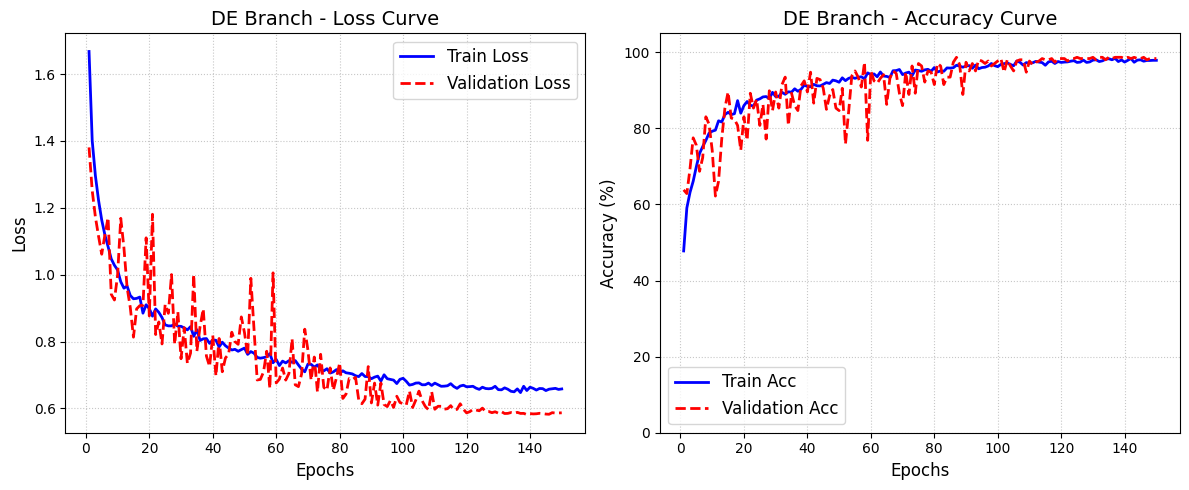

In [4]:
# 建议跑 120 轮，让模型充分收敛
history_DE_128= train_model(channel_name="DE", num_epochs=150)

正在使用 cuda 训练 FE 支路模型 (收集完整 4 项指标)...

FE 支路训练完成！最佳验证集准确率: 99.35%

完整 4 指标训练曲线已保存为: full_training_curve_FE.png


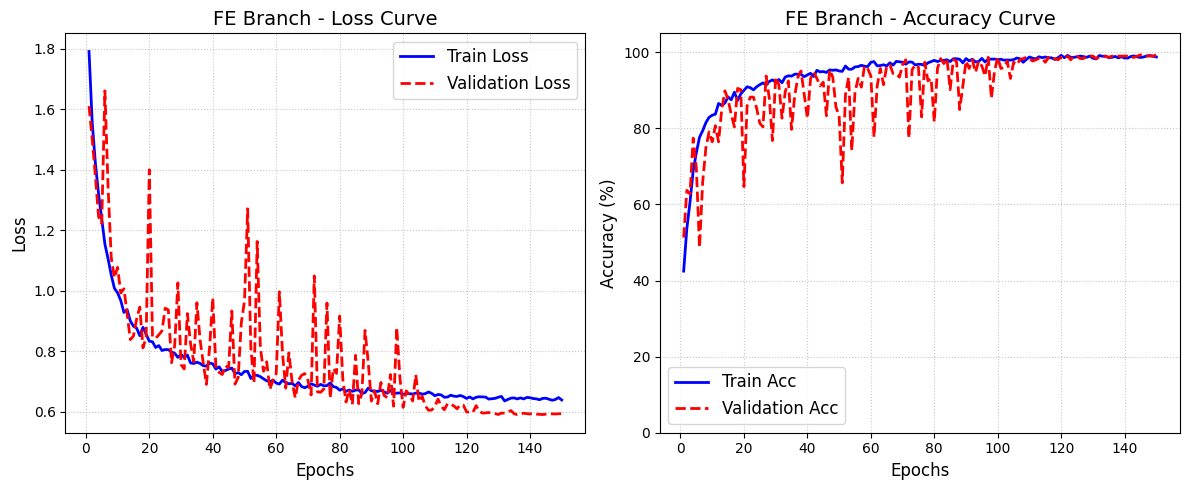

In [5]:
# 建议跑 120 轮，让模型充分收敛
history_FE_128= train_model(channel_name="FE", num_epochs=150)

✨ DE 支路平滑图像已保存为: full_training_curve_DE_smoothed.png


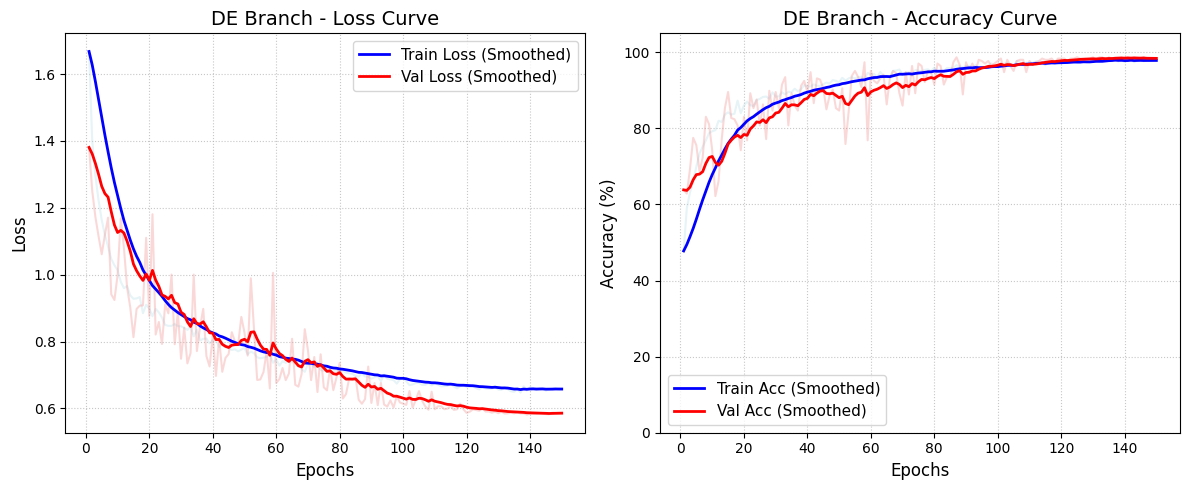

✨ FE 支路平滑图像已保存为: full_training_curve_FE_smoothed.png


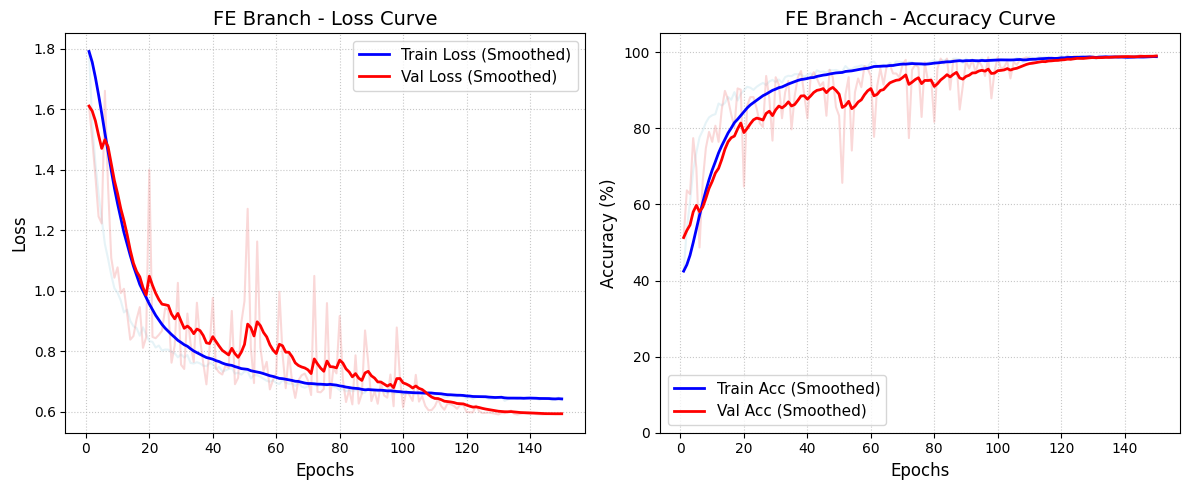

In [6]:
import matplotlib.pyplot as plt

def smooth_curve(points, factor=0.85):
    """指数移动平均平滑算法"""
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

def plot_full_training_curve_smoothed(history, channel_name="DE", smooth_factor=0.85):
    """
    修正说明：
    1. 统一了参数名为 channel_name
    2. 修复了原代码中 f-string 引用变量不一致的问题
    3. 修复了逗号字符错误
    """
    epochs = range(1, len(history['train_loss']) + 1)
    
    # 对 4 项指标分别进行平滑处理
    s_train_loss = smooth_curve(history['train_loss'], factor=smooth_factor)
    s_val_loss = smooth_curve(history['val_loss'], factor=smooth_factor)
    s_train_acc = smooth_curve(history['train_acc'], factor=smooth_factor)
    s_val_acc = smooth_curve(history['val_acc'], factor=smooth_factor)
    
    plt.figure(figsize=(12, 5))
    
    # ==================== 左图：Loss 曲线 ====================
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], color='lightblue', alpha=0.3)
    plt.plot(epochs, history['val_loss'], color='lightcoral', alpha=0.3)
    plt.plot(epochs, s_train_loss, label='Train Loss (Smoothed)', color='blue', linewidth=2)
    plt.plot(epochs, s_val_loss, label='Val Loss (Smoothed)', color='red', linewidth=2)
    
    plt.title(f'{channel_name} Branch - Loss Curve', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(fontsize=11)
    
    # ==================== 右图：Accuracy 曲线 ====================
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], color='lightblue', alpha=0.3)
    plt.plot(epochs, history['val_acc'], color='lightcoral', alpha=0.3)
    plt.plot(epochs, s_train_acc, label='Train Acc (Smoothed)', color='blue', linewidth=2)
    plt.plot(epochs, s_val_acc, label='Val Acc (Smoothed)', color='red', linewidth=2)
    
    plt.title(f'{channel_name} Branch - Accuracy Curve', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.ylim(0, 105)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(fontsize=11)
    
    plt.tight_layout()
    save_path = f'full_training_curve_{channel_name}_smoothed.png'
    plt.savefig(save_path, dpi=300)
    print(f"✨ {channel_name} 支路平滑图像已保存为: {save_path}")
    plt.show()

# ==========================================
# 🚀 分别执行 DE 和 FE 的绘图指令
# ==========================================

# 1. 绘制驱动端 (DE) 图像
# 确保您已经运行了训练代码并得到了 history_DE_128
if 'history_DE_128' in locals():
    plot_full_training_curve_smoothed(history_DE_128, channel_name="DE")

# 2. 绘制风扇端 (FE) 图像
# 确保您已经运行了训练代码并得到了 history_FE_128
if 'history_FE_128' in locals():
    plot_full_training_curve_smoothed(history_FE_128, channel_name="FE")

# 绘制混淆矩阵

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score
from torch.utils.data import DataLoader

成功加载模型权重: best_model_DE.pth

--- DE 支路分类性能报告 ---
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000       189
      IR_007     1.0000    1.0000    1.0000        47
      IR_014     0.9792    1.0000    0.9895        47
      IR_021     1.0000    1.0000    1.0000        47
       B_007     0.9762    0.8542    0.9111        48
       B_014     0.9600    1.0000    0.9796        48
       B_021     0.8864    0.8298    0.8571        47
      OR_007     1.0000    1.0000    1.0000        48
      OR_014     0.8704    0.9792    0.9216        48
      OR_021     1.0000    1.0000    1.0000        47

    accuracy                         0.9740       616
   macro avg     0.9672    0.9663    0.9659       616
weighted avg     0.9747    0.9740    0.9737       616

混淆矩阵已保存为: confusion_matrix_DE_final.png


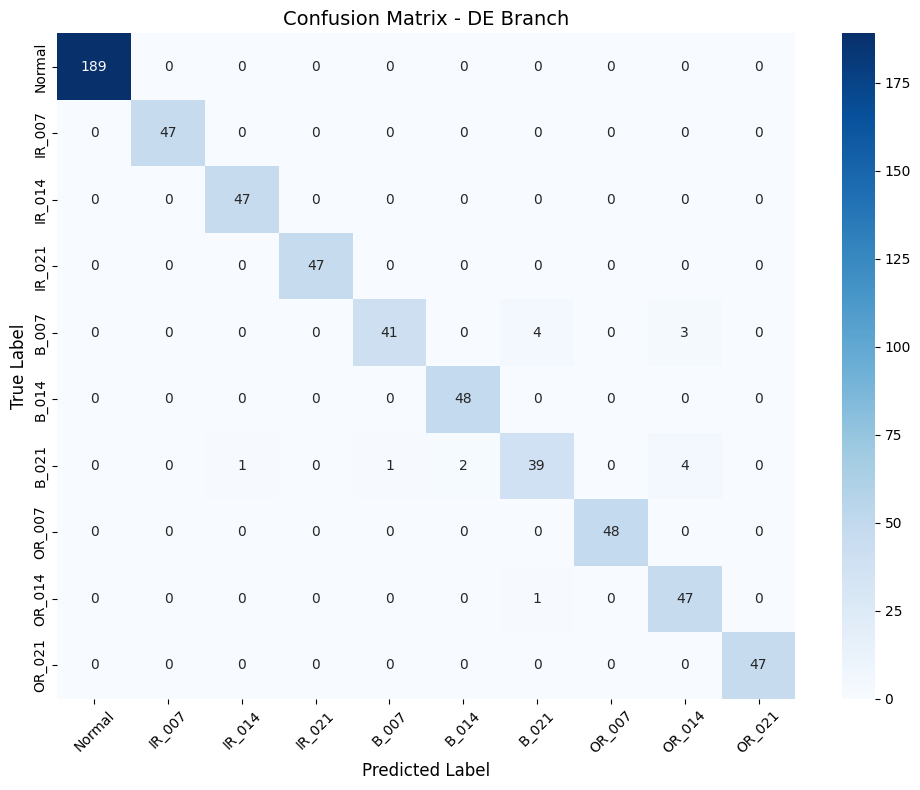

成功加载模型权重: best_model_FE.pth

--- FE 支路分类性能报告 ---
              precision    recall  f1-score   support

      Normal     1.0000    1.0000    1.0000       189
      IR_007     1.0000    1.0000    1.0000        47
      IR_014     1.0000    0.9787    0.9892        47
      IR_021     0.9792    1.0000    0.9895        47
       B_007     1.0000    0.8723    0.9318        47
       B_014     0.9388    0.9583    0.9485        48
       B_021     0.8824    0.9574    0.9184        47
      OR_007     0.9783    0.9574    0.9677        47
      OR_014     1.0000    1.0000    1.0000        47
      OR_021     0.9592    1.0000    0.9792        47

    accuracy                         0.9788       613
   macro avg     0.9738    0.9724    0.9724       613
weighted avg     0.9798    0.9788    0.9788       613

混淆矩阵已保存为: confusion_matrix_FE_final.png


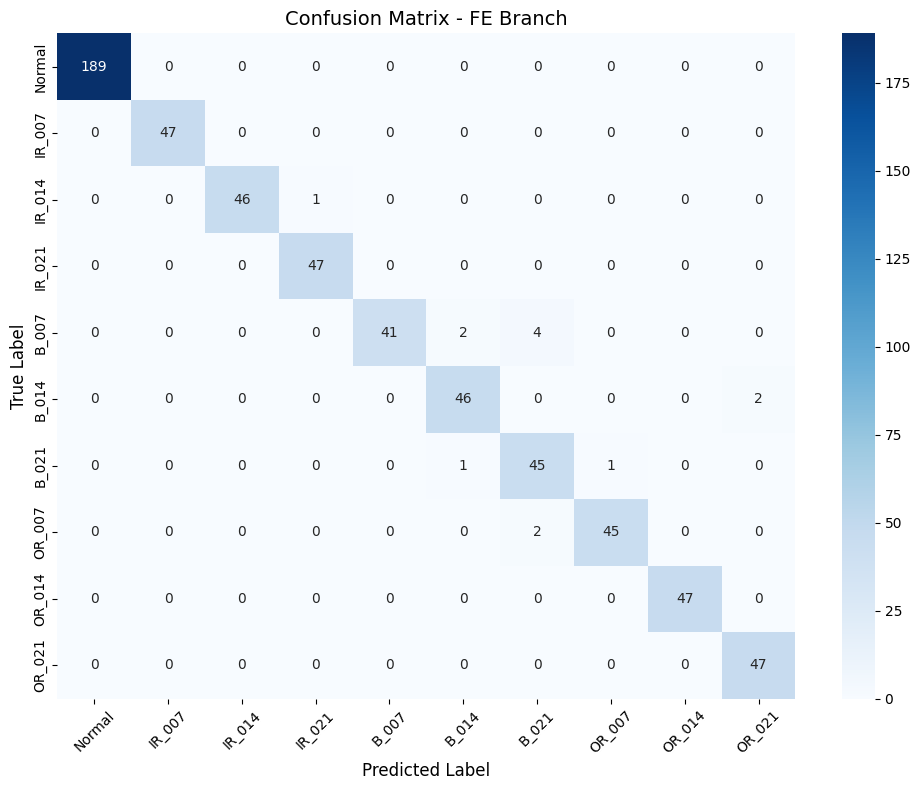

In [8]:
def evaluate_and_plot_metrics(channel_name="DE", model_path=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. 加载测试数据
    _, _, test_data = load_data(channel=channel_name)
    test_loader = DataLoader(GAFDataset(*test_data), batch_size=32, shuffle=False)
    
    # 2. 初始化模型并加载权重
    model = MSMorlet_SE_CNN(num_classes=10).to(device)
    if model_path is None:
        model_path = f"best_model_{channel_name}.pth"
    
    try:
        model.load_state_dict(torch.load(model_path))
        print(f"成功加载模型权重: {model_path}")
    except FileNotFoundError:
        print(f"错误：未找到模型权重文件 {model_path}，请确认已完成训练。")
        return

    model.eval()
    
    all_preds = []
    all_labels = []
    
    # 3. 收集预测结果
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # 4. 计算并打印分类报告 (Precision, Recall, F1)
    class_names = list(LABEL_MAP.keys())
    print(f"\n--- {channel_name} 支路分类性能报告 ---")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
    
    # 5. 绘制混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {channel_name} Branch', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # 保存结果图
    save_path = f'confusion_matrix_{channel_name}_final.png'
    plt.savefig(save_path, dpi=300)
    print(f"混淆矩阵已保存为: {save_path}")
    plt.show()

# ==========================================
# 运行评估示例
# ==========================================
# 评估驱动端 (DE)
evaluate_and_plot_metrics(channel_name="DE")

# 评估风扇端 (FE)
evaluate_and_plot_metrics(channel_name="FE")

# 10次平均实验

开始执行原模型（MSMorlet-SE-CNN）性能测试，共计 10 次任务...

>>> 正在进行第 1/10 次运行...
正在使用 cuda 训练 DE 支路模型...
训练集样本数: 1490, 验证集样本数: 213

DE 支路训练完成！最佳验证集准确率: 97.65%

带平滑效果的训练曲线已保存为: training_curve_DE_final.png


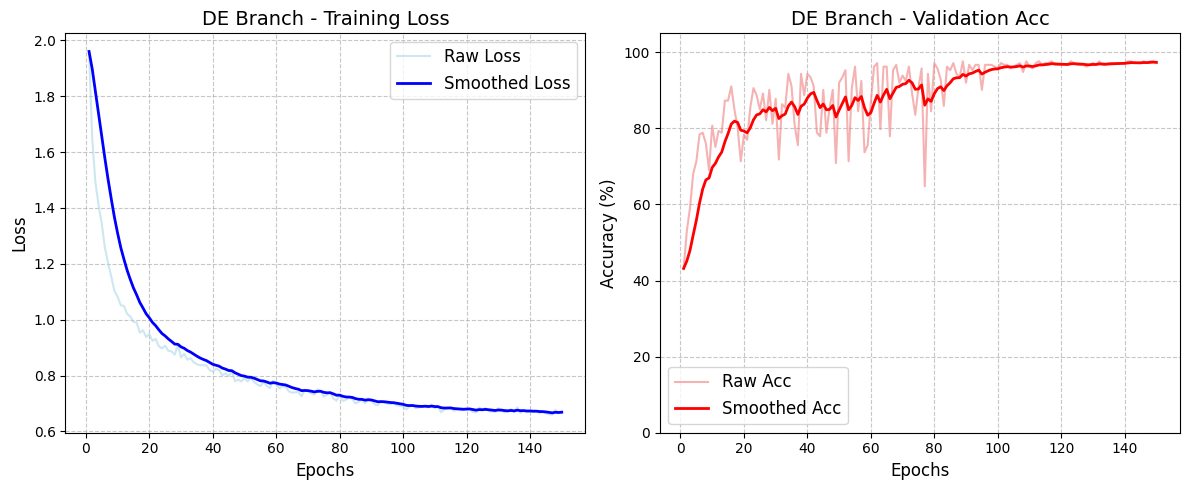

>>> 第 1 次运行耗时: 105.05 秒 (1.75 分钟)

>>> 正在进行第 2/10 次运行...
正在使用 cuda 训练 DE 支路模型...
训练集样本数: 1490, 验证集样本数: 213

DE 支路训练完成！最佳验证集准确率: 98.12%

带平滑效果的训练曲线已保存为: training_curve_DE_final.png


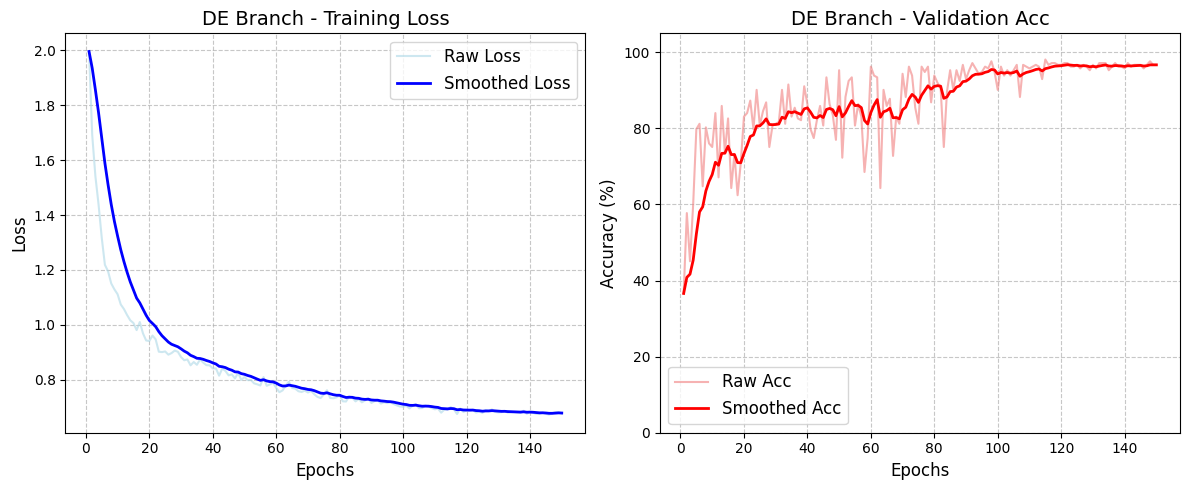

>>> 第 2 次运行耗时: 106.98 秒 (1.78 分钟)

>>> 正在进行第 3/10 次运行...
正在使用 cuda 训练 DE 支路模型...
训练集样本数: 1490, 验证集样本数: 213

DE 支路训练完成！最佳验证集准确率: 97.65%

带平滑效果的训练曲线已保存为: training_curve_DE_final.png


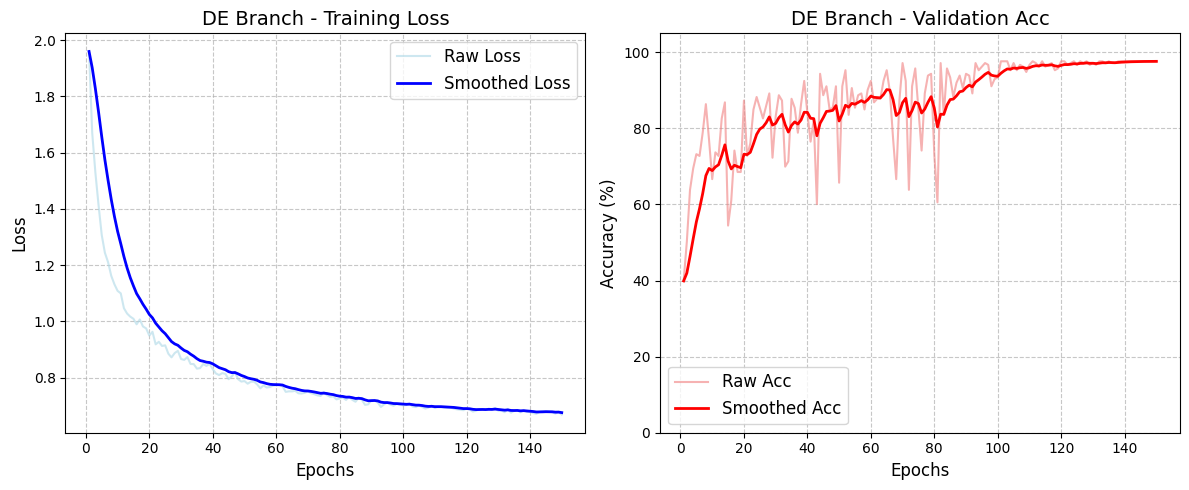

>>> 第 3 次运行耗时: 108.29 秒 (1.80 分钟)

>>> 正在进行第 4/10 次运行...
正在使用 cuda 训练 DE 支路模型...
训练集样本数: 1490, 验证集样本数: 213

DE 支路训练完成！最佳验证集准确率: 97.65%

带平滑效果的训练曲线已保存为: training_curve_DE_final.png


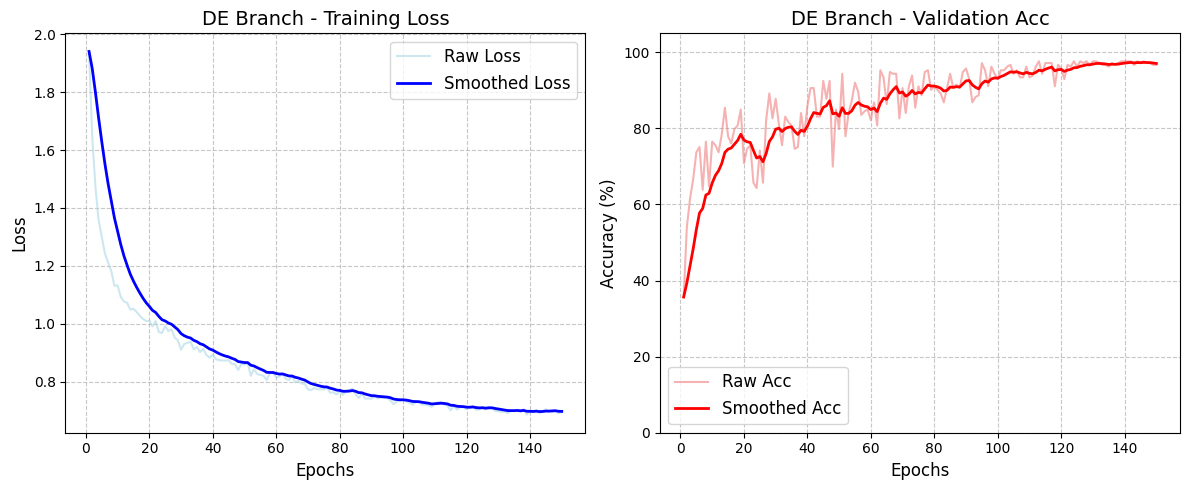

>>> 第 4 次运行耗时: 106.70 秒 (1.78 分钟)

>>> 正在进行第 5/10 次运行...
正在使用 cuda 训练 DE 支路模型...
训练集样本数: 1490, 验证集样本数: 213

DE 支路训练完成！最佳验证集准确率: 97.65%

带平滑效果的训练曲线已保存为: training_curve_DE_final.png


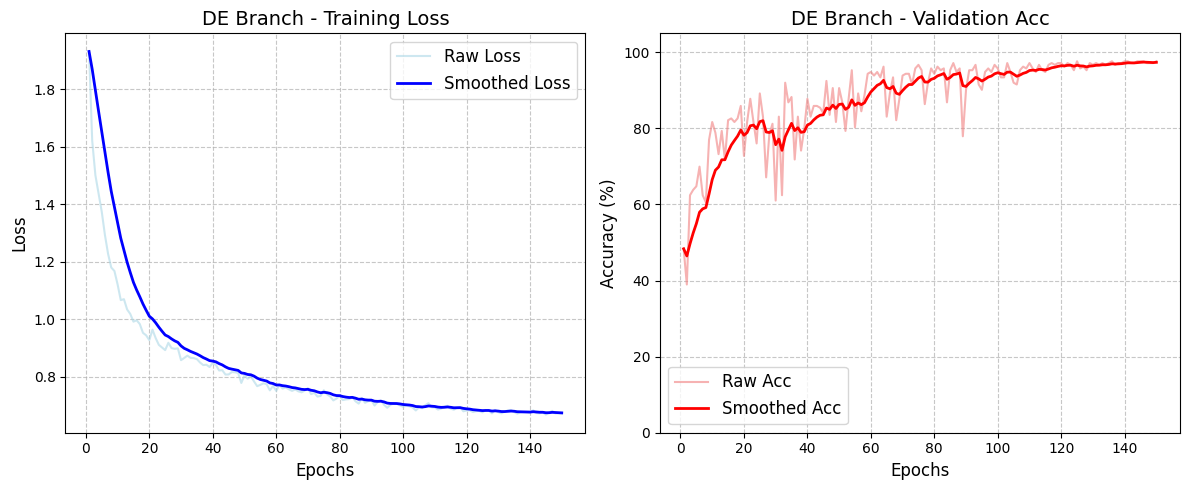

>>> 第 5 次运行耗时: 105.29 秒 (1.75 分钟)

>>> 正在进行第 6/10 次运行...
正在使用 cuda 训练 DE 支路模型...
训练集样本数: 1490, 验证集样本数: 213

DE 支路训练完成！最佳验证集准确率: 97.65%

带平滑效果的训练曲线已保存为: training_curve_DE_final.png


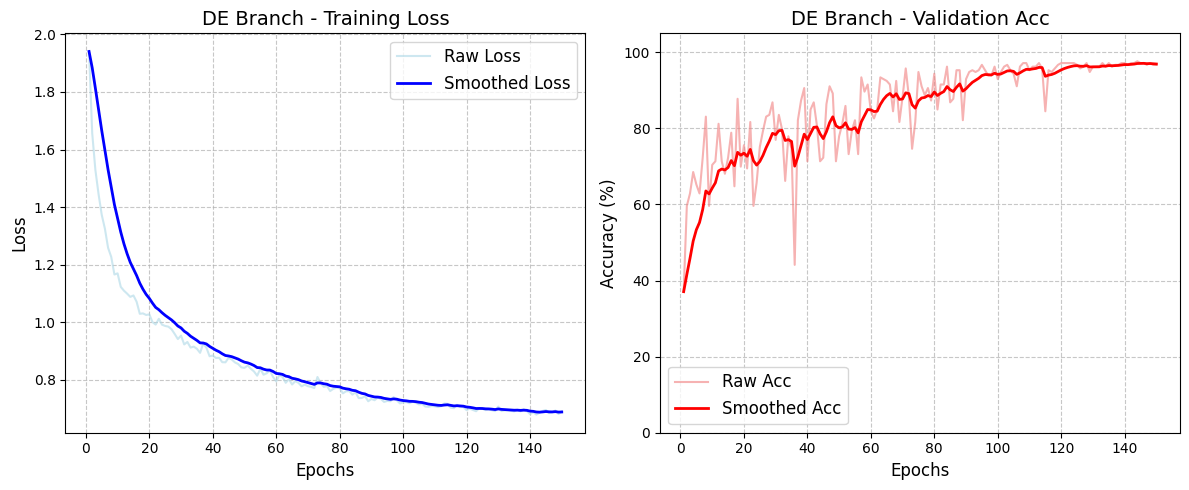

>>> 第 6 次运行耗时: 107.08 秒 (1.78 分钟)

>>> 正在进行第 7/10 次运行...
正在使用 cuda 训练 DE 支路模型...
训练集样本数: 1490, 验证集样本数: 213

DE 支路训练完成！最佳验证集准确率: 98.59%

带平滑效果的训练曲线已保存为: training_curve_DE_final.png


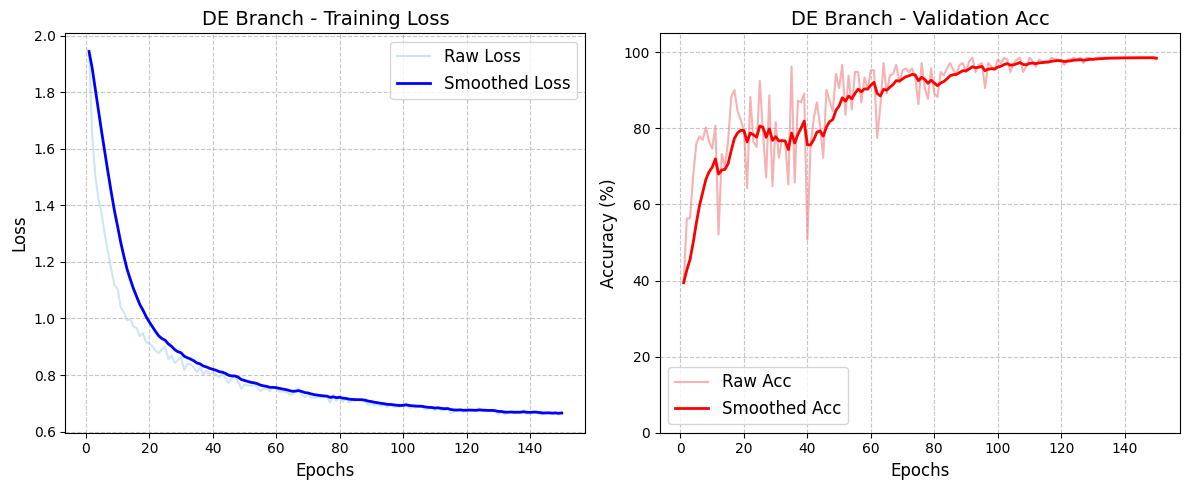

>>> 第 7 次运行耗时: 106.73 秒 (1.78 分钟)

>>> 正在进行第 8/10 次运行...
正在使用 cuda 训练 DE 支路模型...
训练集样本数: 1490, 验证集样本数: 213

DE 支路训练完成！最佳验证集准确率: 97.18%

带平滑效果的训练曲线已保存为: training_curve_DE_final.png


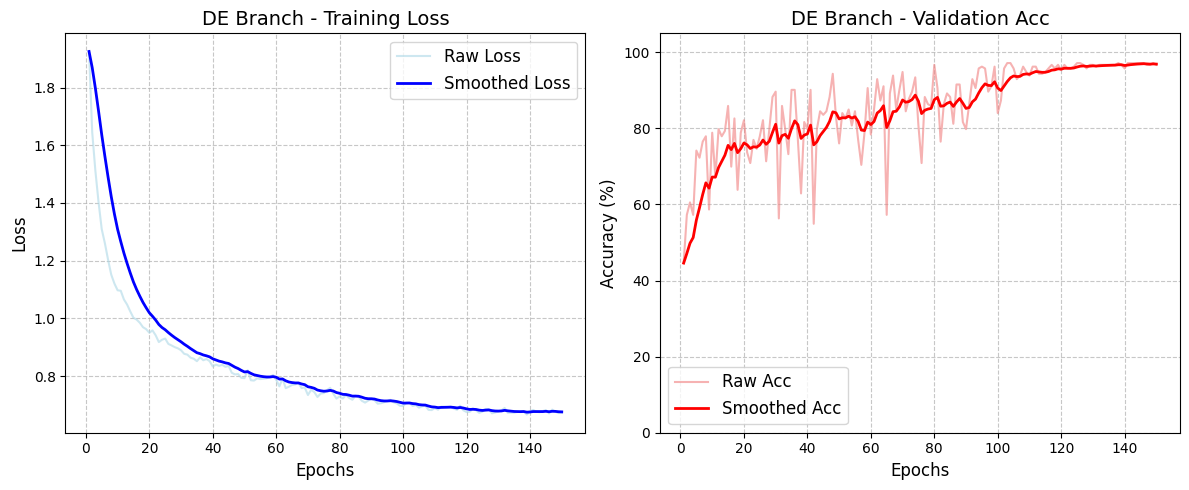

>>> 第 8 次运行耗时: 107.62 秒 (1.79 分钟)

>>> 正在进行第 9/10 次运行...
正在使用 cuda 训练 DE 支路模型...
训练集样本数: 1490, 验证集样本数: 213

DE 支路训练完成！最佳验证集准确率: 97.65%

带平滑效果的训练曲线已保存为: training_curve_DE_final.png


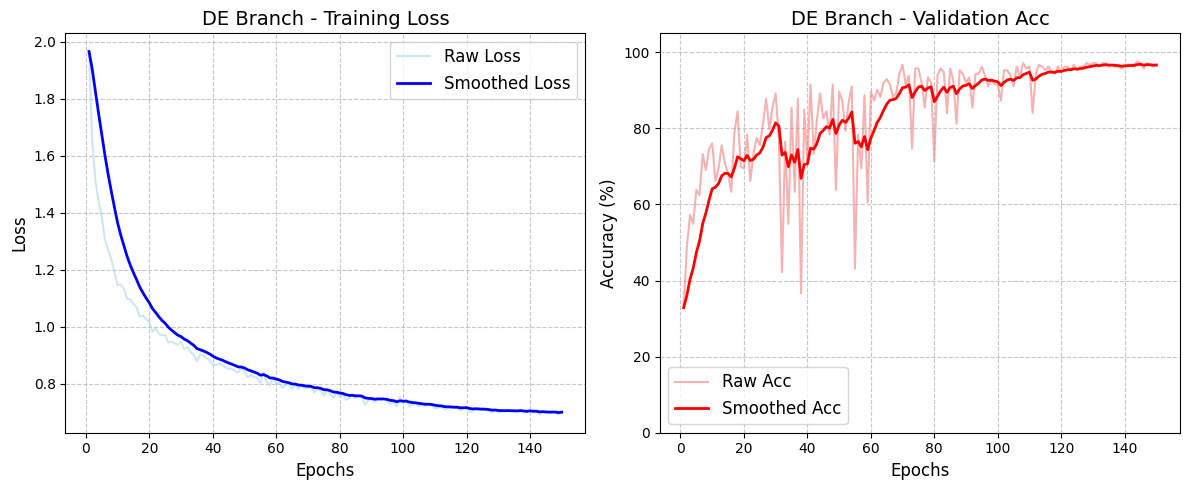

>>> 第 9 次运行耗时: 107.87 秒 (1.80 分钟)

>>> 正在进行第 10/10 次运行...
正在使用 cuda 训练 DE 支路模型...
训练集样本数: 1490, 验证集样本数: 213

DE 支路训练完成！最佳验证集准确率: 97.65%

带平滑效果的训练曲线已保存为: training_curve_DE_final.png


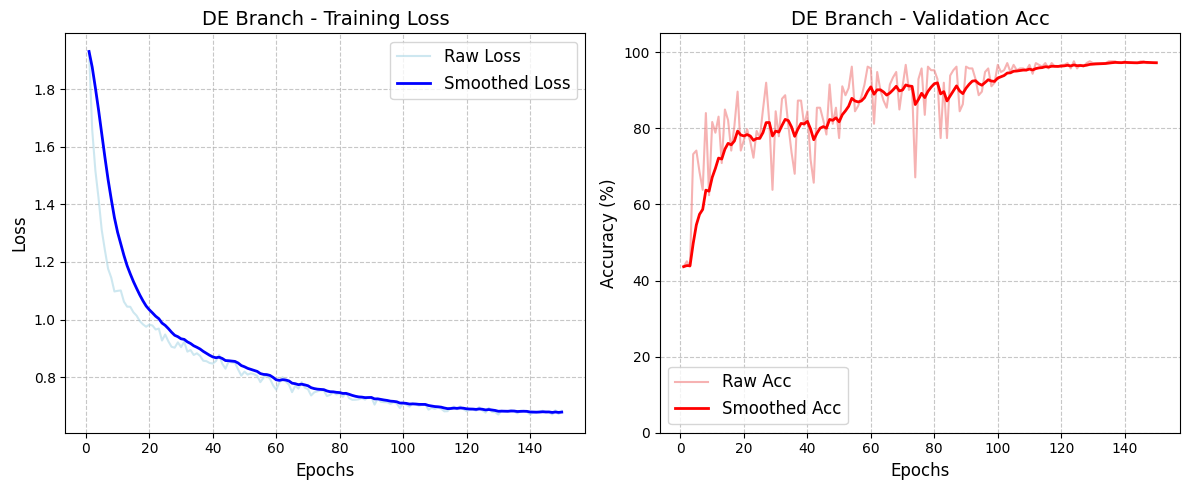

>>> 第 10 次运行耗时: 105.50 秒 (1.76 分钟)

原模型 10 次运行时间统计
   Run_ID                Model_Type Channel  Epochs  Duration_Seconds  \
0       1  Original_MSMorlet_SE_CNN      DE     150            105.05   
1       2  Original_MSMorlet_SE_CNN      DE     150            106.98   
2       3  Original_MSMorlet_SE_CNN      DE     150            108.29   
3       4  Original_MSMorlet_SE_CNN      DE     150            106.70   
4       5  Original_MSMorlet_SE_CNN      DE     150            105.29   
5       6  Original_MSMorlet_SE_CNN      DE     150            107.08   
6       7  Original_MSMorlet_SE_CNN      DE     150            106.73   
7       8  Original_MSMorlet_SE_CNN      DE     150            107.62   
8       9  Original_MSMorlet_SE_CNN      DE     150            107.87   
9      10  Original_MSMorlet_SE_CNN      DE     150            105.50   

   Duration_Minutes  
0              1.75  
1              1.78  
2              1.80  
3              1.78  
4              1.75  
5            

In [42]:
import time
import pandas as pd

# 用于存储运行时间的列表
original_model_times = []

# 定义实验参数
num_runs = 10
epochs_per_run = 150 # 如果仅为了测试代码逻辑，可以先改为 1
channel = "DE"

print(f"开始执行原模型（MSMorlet-SE-CNN）性能测试，共计 {num_runs} 次任务...")

for i in range(1, num_runs + 1):
    print(f"\n>>> 正在进行第 {i}/{num_runs} 次运行...")
    
    # 记录起始时间
    start_ts = time.time()
    
    # 调用原模型的训练函数 (根据你的代码，原训练函数名为 train_model)
    # 注意：这里会包含训练和验证的完整耗时
    train_model(channel_name=channel, num_epochs=epochs_per_run)
    
    # 记录结束时间
    end_ts = time.time()
    
    duration = end_ts - start_ts
    original_model_times.append({
        "Run_ID": i,
        "Model_Type": "Original_MSMorlet_SE_CNN",
        "Channel": channel,
        "Epochs": epochs_per_run,
        "Duration_Seconds": round(duration, 2),
        "Duration_Minutes": round(duration / 60, 2)
    })
    
    print(f">>> 第 {i} 次运行耗时: {duration:.2f} 秒 ({duration/60:.2f} 分钟)")

# 汇总并展示结果
df_original_results = pd.DataFrame(original_model_times)

print("\n" + "="*50)
print("原模型 10 次运行时间统计")
print("="*50)
print(df_original_results)

# 计算平均耗时
avg_time = df_original_results["Duration_Seconds"].mean()
print(f"\n平均单次运行耗时: {avg_time:.2f} 秒 ({avg_time/60:.2f} 分钟)")

# 保存为 CSV 文件
df_original_results.to_csv("original_model_10runs_time.csv", index=False, encoding='utf-8-sig')
print("\n结果已保存至本地文件: original_model_10runs_time.csv")

开始执行原模型（MSMorlet-SE-CNN）性能测试，共计 10 次任务...

>>> 正在进行第 1/10 次运行...
正在使用 cuda 训练 FE 支路模型...
训练集样本数: 1481, 验证集样本数: 212

FE 支路训练完成！最佳验证集准确率: 99.06%

带平滑效果的训练曲线已保存为: training_curve_FE_final.png


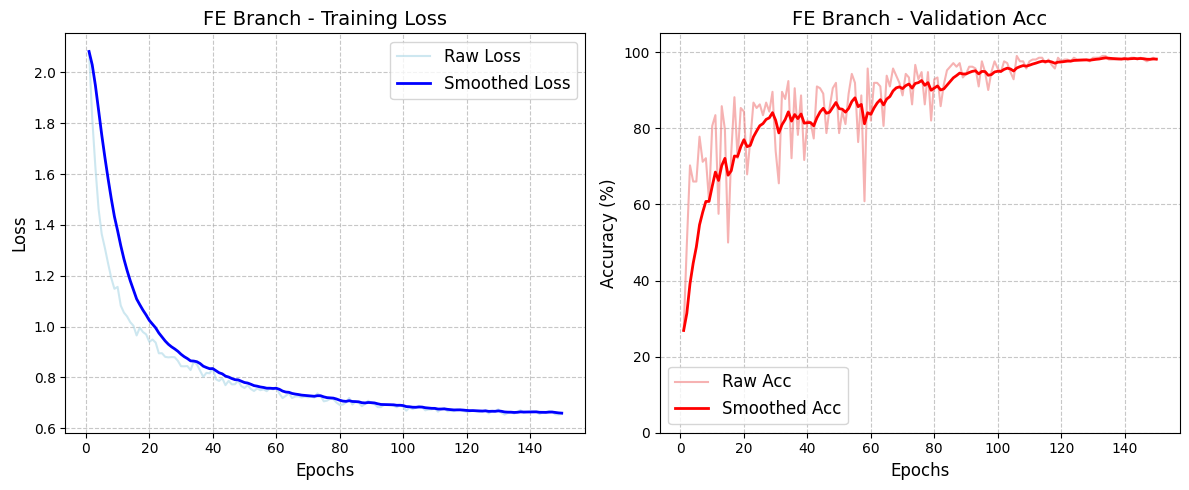

>>> 第 1 次运行耗时: 109.26 秒 (1.82 分钟)

>>> 正在进行第 2/10 次运行...
正在使用 cuda 训练 FE 支路模型...
训练集样本数: 1481, 验证集样本数: 212

FE 支路训练完成！最佳验证集准确率: 97.64%

带平滑效果的训练曲线已保存为: training_curve_FE_final.png


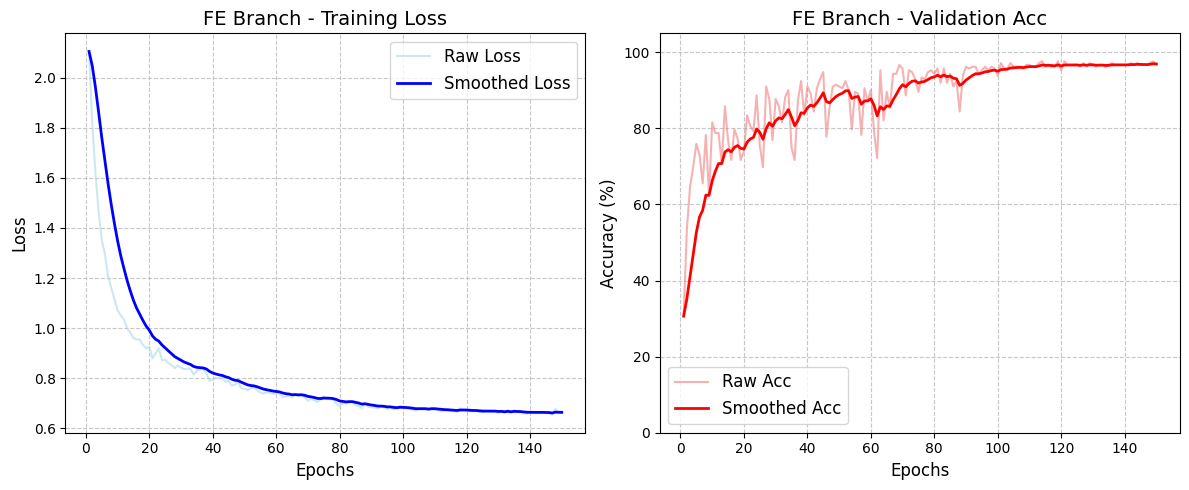

>>> 第 2 次运行耗时: 105.66 秒 (1.76 分钟)

>>> 正在进行第 3/10 次运行...
正在使用 cuda 训练 FE 支路模型...
训练集样本数: 1481, 验证集样本数: 212

FE 支路训练完成！最佳验证集准确率: 98.11%

带平滑效果的训练曲线已保存为: training_curve_FE_final.png


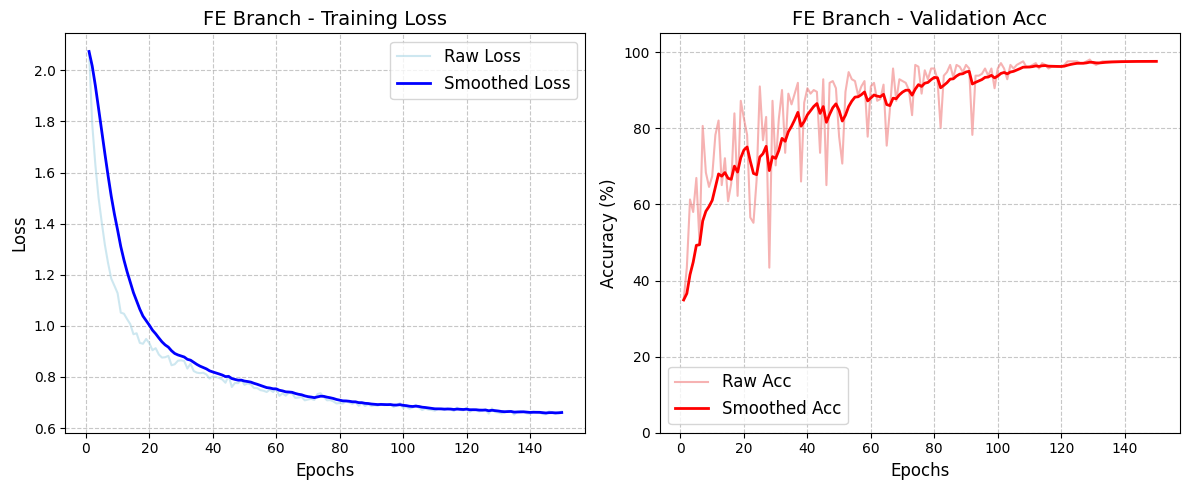

>>> 第 3 次运行耗时: 104.63 秒 (1.74 分钟)

>>> 正在进行第 4/10 次运行...
正在使用 cuda 训练 FE 支路模型...
训练集样本数: 1481, 验证集样本数: 212

FE 支路训练完成！最佳验证集准确率: 97.17%

带平滑效果的训练曲线已保存为: training_curve_FE_final.png


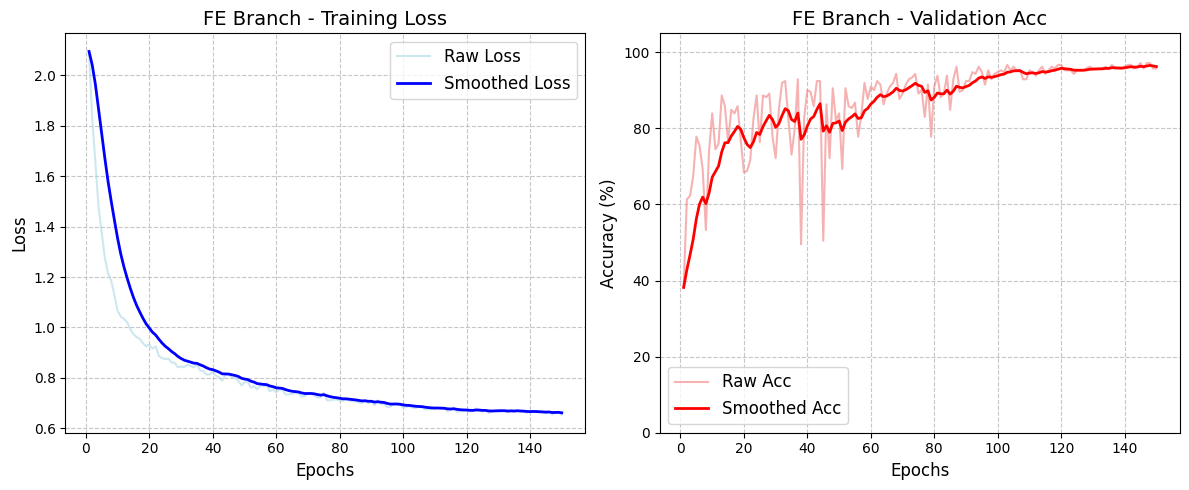

>>> 第 4 次运行耗时: 104.97 秒 (1.75 分钟)

>>> 正在进行第 5/10 次运行...
正在使用 cuda 训练 FE 支路模型...
训练集样本数: 1481, 验证集样本数: 212

FE 支路训练完成！最佳验证集准确率: 97.17%

带平滑效果的训练曲线已保存为: training_curve_FE_final.png


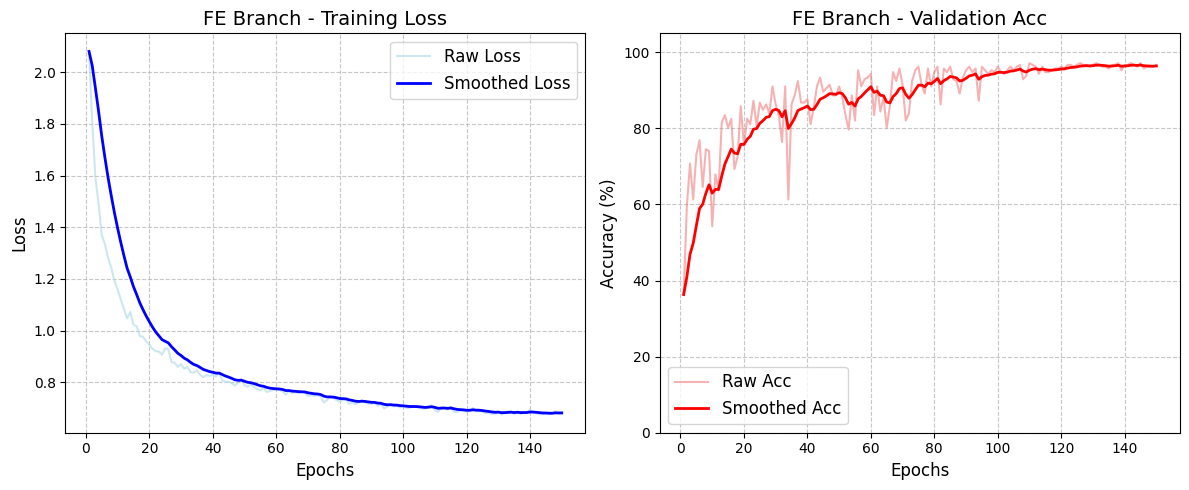

>>> 第 5 次运行耗时: 103.94 秒 (1.73 分钟)

>>> 正在进行第 6/10 次运行...
正在使用 cuda 训练 FE 支路模型...
训练集样本数: 1481, 验证集样本数: 212

FE 支路训练完成！最佳验证集准确率: 98.11%

带平滑效果的训练曲线已保存为: training_curve_FE_final.png


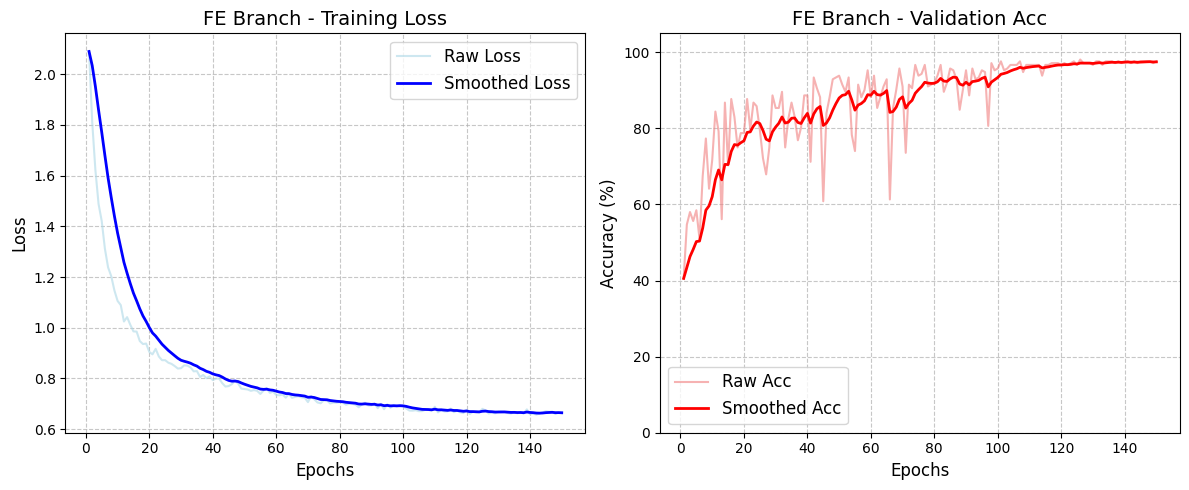

>>> 第 6 次运行耗时: 105.01 秒 (1.75 分钟)

>>> 正在进行第 7/10 次运行...
正在使用 cuda 训练 FE 支路模型...
训练集样本数: 1481, 验证集样本数: 212

FE 支路训练完成！最佳验证集准确率: 97.64%

带平滑效果的训练曲线已保存为: training_curve_FE_final.png


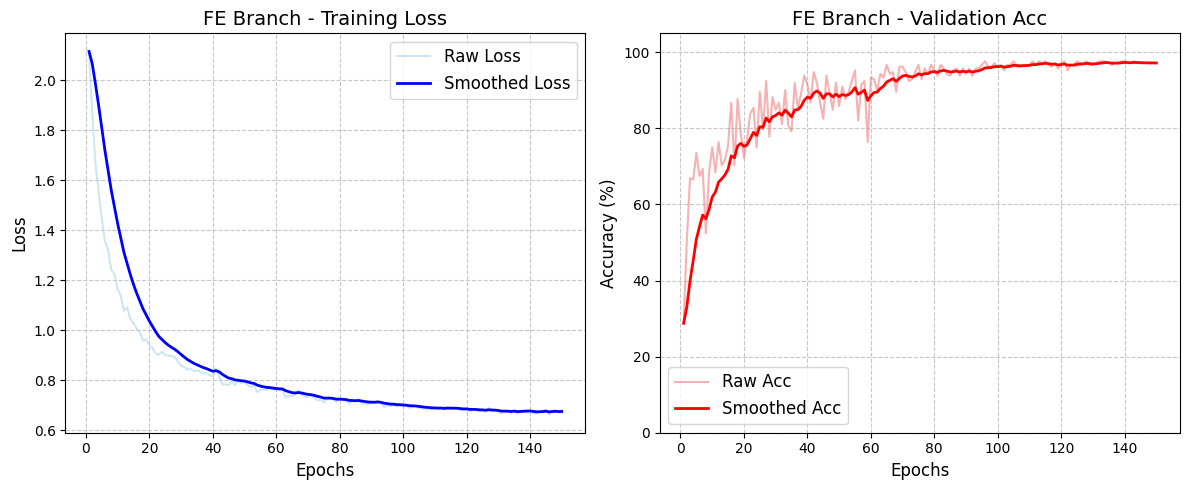

>>> 第 7 次运行耗时: 105.62 秒 (1.76 分钟)

>>> 正在进行第 8/10 次运行...
正在使用 cuda 训练 FE 支路模型...
训练集样本数: 1481, 验证集样本数: 212

FE 支路训练完成！最佳验证集准确率: 97.64%

带平滑效果的训练曲线已保存为: training_curve_FE_final.png


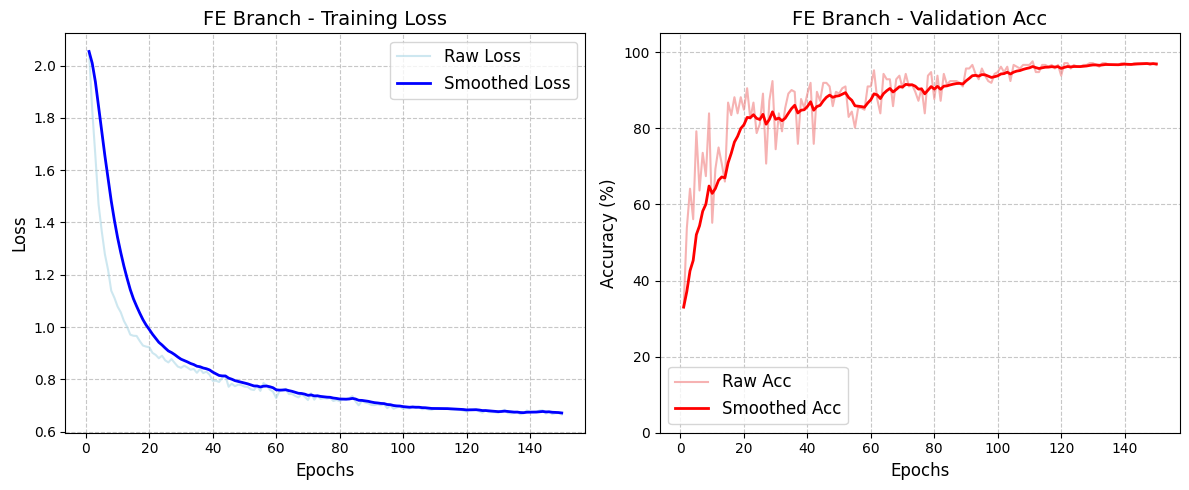

>>> 第 8 次运行耗时: 104.53 秒 (1.74 分钟)

>>> 正在进行第 9/10 次运行...
正在使用 cuda 训练 FE 支路模型...
训练集样本数: 1481, 验证集样本数: 212

FE 支路训练完成！最佳验证集准确率: 98.58%

带平滑效果的训练曲线已保存为: training_curve_FE_final.png


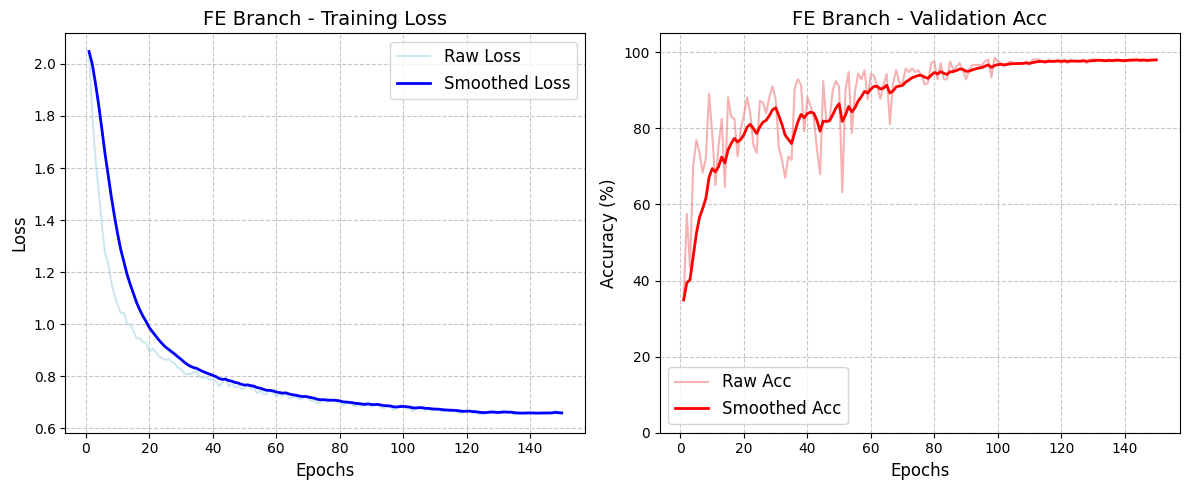

>>> 第 9 次运行耗时: 104.39 秒 (1.74 分钟)

>>> 正在进行第 10/10 次运行...
正在使用 cuda 训练 FE 支路模型...
训练集样本数: 1481, 验证集样本数: 212

FE 支路训练完成！最佳验证集准确率: 98.11%

带平滑效果的训练曲线已保存为: training_curve_FE_final.png


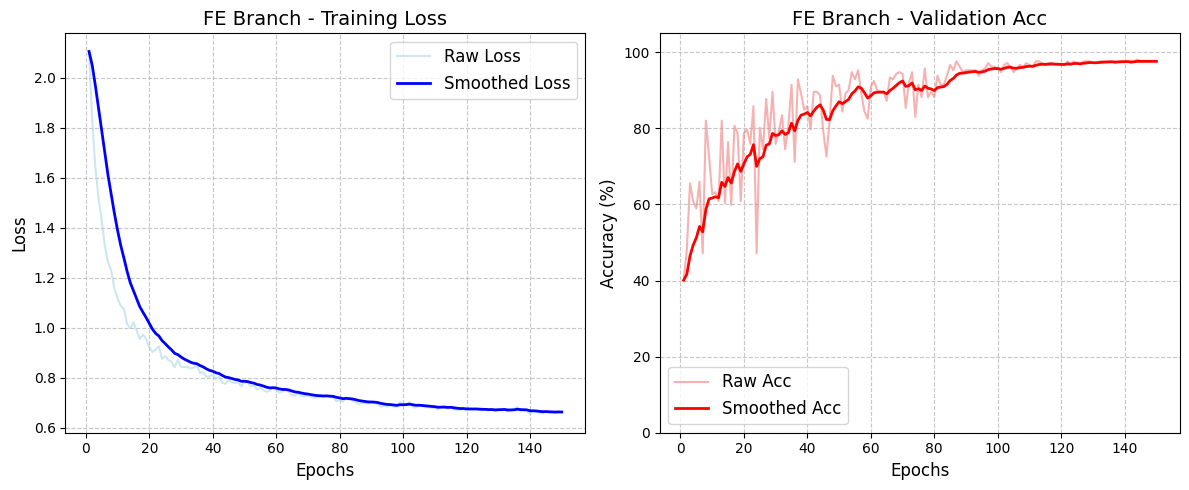

>>> 第 10 次运行耗时: 104.72 秒 (1.75 分钟)

原模型 10 次运行时间统计
   Run_ID                Model_Type Channel  Epochs  Duration_Seconds  \
0       1  Original_MSMorlet_SE_CNN      FE     150            109.26   
1       2  Original_MSMorlet_SE_CNN      FE     150            105.66   
2       3  Original_MSMorlet_SE_CNN      FE     150            104.63   
3       4  Original_MSMorlet_SE_CNN      FE     150            104.97   
4       5  Original_MSMorlet_SE_CNN      FE     150            103.94   
5       6  Original_MSMorlet_SE_CNN      FE     150            105.01   
6       7  Original_MSMorlet_SE_CNN      FE     150            105.62   
7       8  Original_MSMorlet_SE_CNN      FE     150            104.53   
8       9  Original_MSMorlet_SE_CNN      FE     150            104.39   
9      10  Original_MSMorlet_SE_CNN      FE     150            104.72   

   Duration_Minutes  
0              1.82  
1              1.76  
2              1.74  
3              1.75  
4              1.73  
5            

In [45]:
import time
import pandas as pd

# 用于存储运行时间的列表
original_model_times = []

# 定义实验参数
num_runs = 10
epochs_per_run = 150 # 如果仅为了测试代码逻辑，可以先改为 1
channel = "FE"

print(f"开始执行原模型（MSMorlet-SE-CNN）性能测试，共计 {num_runs} 次任务...")

for i in range(1, num_runs + 1):
    print(f"\n>>> 正在进行第 {i}/{num_runs} 次运行...")
    
    # 记录起始时间
    start_ts = time.time()
    
    # 调用原模型的训练函数 (根据你的代码，原训练函数名为 train_model)
    # 注意：这里会包含训练和验证的完整耗时
    train_model(channel_name=channel, num_epochs=epochs_per_run)
    
    # 记录结束时间
    end_ts = time.time()
    
    duration = end_ts - start_ts
    original_model_times.append({
        "Run_ID": i,
        "Model_Type": "Original_MSMorlet_SE_CNN",
        "Channel": channel,
        "Epochs": epochs_per_run,
        "Duration_Seconds": round(duration, 2),
        "Duration_Minutes": round(duration / 60, 2)
    })
    
    print(f">>> 第 {i} 次运行耗时: {duration:.2f} 秒 ({duration/60:.2f} 分钟)")

# 汇总并展示结果
df_original_results = pd.DataFrame(original_model_times)

print("\n" + "="*50)
print("原模型 10 次运行时间统计")
print("="*50)
print(df_original_results)

# 计算平均耗时
avg_time = df_original_results["Duration_Seconds"].mean()
print(f"\n平均单次运行耗时: {avg_time:.2f} 秒 ({avg_time/60:.2f} 分钟)")

# 保存为 CSV 文件
df_original_results.to_csv("original_model_10runs_time.csv", index=False, encoding='utf-8-sig')
print("\n结果已保存至本地文件: original_model_10runs_time.csv")